# AtliQ Hardware — Sales, Margin & Concentration Risk

**The question this notebook answers:** AtliQ's revenue looks healthy at ~₹98 Cr. So why is the business fragile?

This notebook loads the raw transaction dump, cleans it, and walks top-to-bottom through five findings, each ending in a decision. It imports the reusable functions in [`../src`](../src) so the logic is tested in one place and the narrative stays readable. **Restart & Run All** reproduces every number and figure in the README.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
import pandas as pd
from IPython.display import Image
from data_loader import build_fact, write_processed
import metrics as M
import viz as V
pd.options.display.float_format = lambda x: f'{x:,.2f}'

fact = build_fact()           # parse dump -> clean, INR-normalised fact table
write_processed(fact)         # persist data/processed/transactions_clean.csv (Tableau-ready)
h = M.headline(fact)
print(f"{h['transactions']:,} transactions | {h['date_min']} -> {h['date_max']}")
print(f"Revenue ₹{h['revenue_cr']:.0f} Cr | margin {h['overall_margin_pct']:.2f}% | "
      f"{h['n_customers']} customers, {h['n_markets']} markets, {h['n_products']} products")

148,395 transactions | 2017-10-04 -> 2020-06-26
Revenue ₹98 Cr | margin 2.61% | 38 customers, 14 markets, 338 products


## Finding 1 — One customer is 42% of revenue

Before optimising anything, ask *where the money actually comes from*. A Pareto on customer revenue shows the business is not diversified — it rests on a single account.

,rank,customer_name,revenue,share_pct,cum_share_pct
0,1,Electricalsara Stores,"413,333,588.00",41.97,41.97
1,2,Electricalslytical,"49,644,189.00",5.04,47.01
2,3,Excel Stores,"49,115,620.00",4.99,52.00
3,4,Premium Stores,"44,962,166.00",4.57,56.56
4,5,Nixon,"43,893,083.00",4.46,61.02


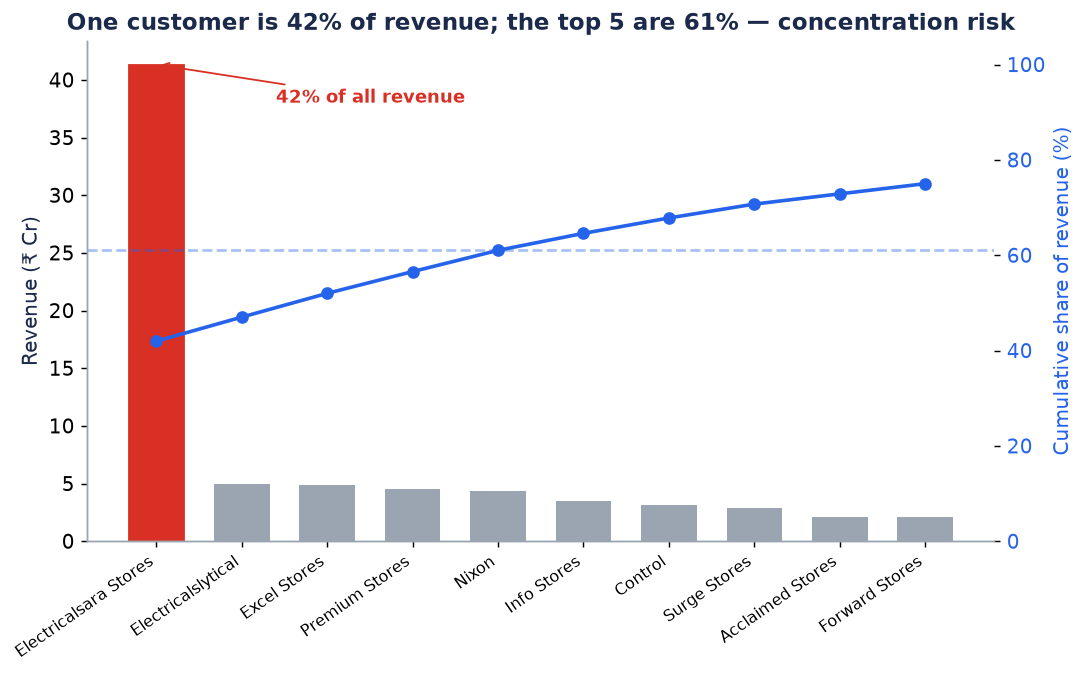

In [2]:
conc = M.customer_concentration(fact)
display(conc.head(5)[['rank','customer_name','revenue','share_pct','cum_share_pct']])
V.fig_customer_concentration(conc)
Image('../reports/figures/01_customer_concentration.png')

> **So what:** *Electricalsara Stores* alone is **42%** of revenue and the top 5 are **61%**. Losing the top account would erase nearly half the business overnight. **Decision:** treat account diversification as a board-level risk, not a sales nicety.

## Finding 2 — Two markets sell at a loss

A 2.6% blended margin can hide markets that destroy value. Ranking markets by margin exposes them.

,markets_name,revenue_cr,margin_pct
0,Delhi NCR,51.96,2.51
1,Mumbai,15.01,3.25
2,Ahmedabad,13.23,2.15
3,Bhopal,5.86,3.90
4,Nagpur,5.50,2.57
5,Kochi,1.88,3.74
6,Chennai,1.80,1.67
7,Kanpur,1.36,-0.49
8,Hyderabad,0.74,0.63
9,Patna,0.44,4.12


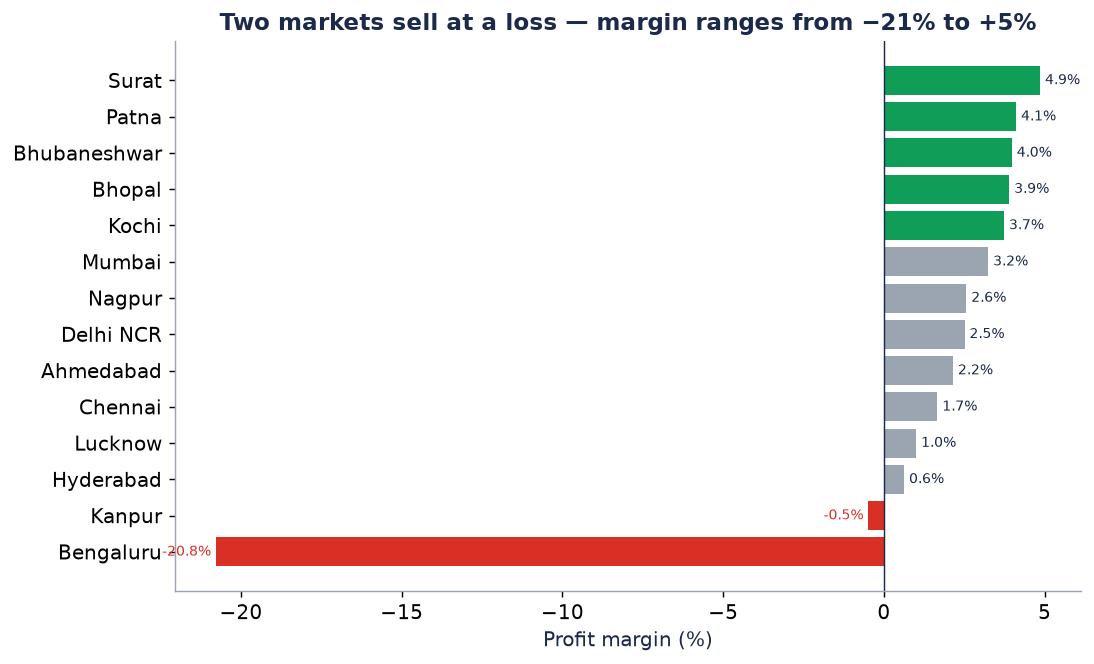

In [3]:
mm = M.margin_by_market(fact)
display(mm[['markets_name','revenue_cr','margin_pct']])
V.fig_margin_by_market(mm)
Image('../reports/figures/02_margin_by_market.png')

> **So what:** **Bengaluru (−20.8%)** and **Kanpur (−0.5%)** lose money on every sale. **Decision:** re-price or exit these markets before chasing new growth — each incremental sale there makes the P&L worse.

## Finding 3 — Growth is concentrated in a low-margin region

Revenue share and margin pull in opposite directions across zones.

,zone,revenue,profit,margin_pct,revenue_share_pct
0,North,"675,588,017.00","16,172,412.62",2.39,68.60
1,Central,"263,720,983.00","8,571,899.18",3.25,26.78
2,South,"45,559,963.00","1,008,881.61",2.21,4.63


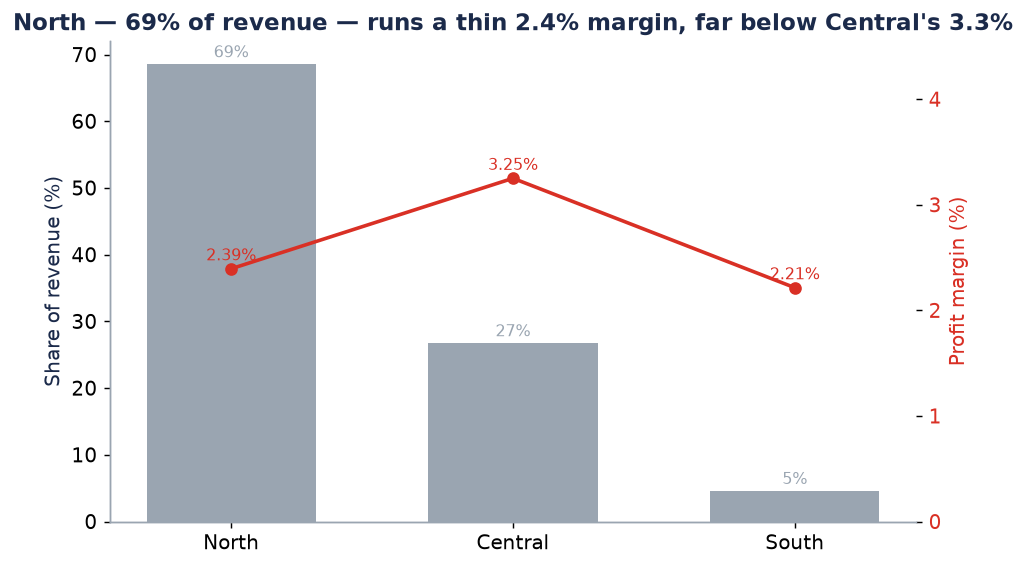

In [4]:
zone = M.margin_by_zone(fact)
display(zone)
V.fig_zone_rev_vs_margin(zone)
Image('../reports/figures/04_zone_revenue_vs_margin.png')

> **So what:** **North** is ~69% of revenue at just **2.4%** margin — far below **Central**'s 3.3% (only the tiny South zone, at 2.2%, is lower). AtliQ's scale sits in its least-profitable major region. **Decision:** shift sales incentives toward Central, where the same effort returns more profit per rupee.

## Finding 4 — E-Commerce is 1.5× more profitable, but under-weighted

Channel margin is a lever the business already controls.

,customer_type,revenue,profit,margin_pct,revenue_share_pct
0,Brick & Mortar,"744,525,338.00","17,278,276.43",2.32,75.60
1,E-Commerce,"240,343,625.00","8,474,916.98",3.53,24.40


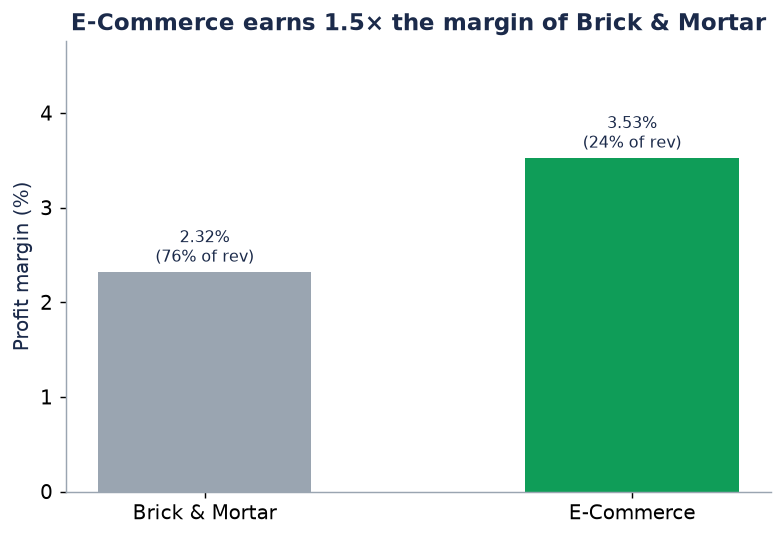

In [5]:
chan = M.margin_by_channel(fact)
display(chan)
V.fig_channel_margin(chan)
Image('../reports/figures/03_channel_margin.png')

> **So what:** E-Commerce earns **3.5%** vs Brick & Mortar **2.3%**, yet is only ~24% of revenue. **Decision:** move marginal volume online — shifting share toward e-commerce margin lifts profit on revenue the business already has.

## Finding 5 — Revenue is shrinking

Comparing only the two full calendar years removes the partial-year distortion.

,year,revenue_cr,partial_year
0,2017,9.29,True
1,2018,41.37,False
2,2019,33.60,False
3,2020,14.22,True


2018 -> 2019 change: -18.8%


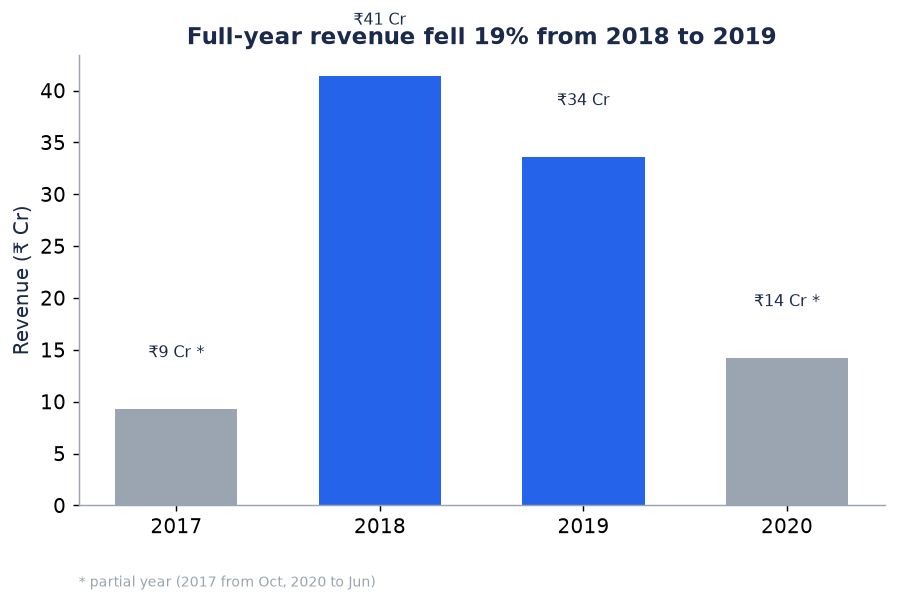

In [6]:
ry = M.revenue_by_year(fact)
display(ry[['year','revenue_cr','partial_year']])
full = ry[~ry['partial_year']].set_index('year')['revenue']
print(f"2018 -> 2019 change: {100*(full.loc[2019]/full.loc[2018]-1):.1f}%")
V.fig_revenue_trend(ry)
Image('../reports/figures/05_revenue_trend.png')

> **So what:** Full-year revenue fell **19%** (2018 → 2019). **Decision:** the concentration and margin fixes above are not optional polish — they are how a *shrinking, low-margin* book is stabilised.

---
## Why this approach (not just a dashboard)
A revenue dashboard would have shown growth and stopped. Ranking by **margin** and **customer concentration** — not revenue — is what surfaced the real risks: the loss-making markets and the single-account dependency were invisible in the topline. That choice of lens is the analysis.

## Honest limitations
- The dump is already clean (no non-positive amounts; only 2 USD rows), so this is not a data-cleaning showcase — it is a *decision* showcase.
- 2017 and 2020 are partial years and are excluded from the trend comparison.
- Margins are as-booked; allocation of overhead/logistics is out of scope and would only deepen the loss-making-market conclusion.